<a href="https://colab.research.google.com/github/NadiiaIvashchuk/Olist-analytics/blob/main/notebook/olist_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part 3. Python: Simple Forecast and Recommendations

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

FILE_IN = "https://raw.githubusercontent.com/NadiiaIvashchuk/Olist-analytics/refs/heads/main/data/main_sales_region.csv"

In [55]:
df = pd.read_csv(FILE_IN)
df.head()

,order_id,order_purchase_t,purch_mon,customer_state,category,price,freight_value,review_score,pay_method,order_status,region
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10,SP,housewares,29.99,8.72,4.0,credit_card,delivered,Southeast
1,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10,SP,housewares,29.99,8.72,4.0,voucher,delivered,Southeast
2,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10,SP,housewares,29.99,8.72,4.0,voucher,delivered,Southeast
3,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07,BA,perfumery,118.70,22.76,4.0,boleto,delivered,Northeast
4,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08,GO,auto,159.90,19.22,5.0,credit_card,delivered,Central-West


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115723 entries, 0 to 115722
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          115723 non-null  object 
 1   order_purchase_t  115723 non-null  object 
 2   purch_mon         115723 non-null  object 
 3   customer_state    115723 non-null  object 
 4   category          114062 non-null  object 
 5   price             115723 non-null  float64
 6   freight_value     115723 non-null  float64
 7   review_score      114862 non-null  float64
 8   pay_method        115720 non-null  object 
 9   order_status      115723 non-null  object 
 10  region            115723 non-null  object 
dtypes: float64(3), object(8)
memory usage: 9.7+ MB


In [57]:
df.isna().sum()

,0
order_id,0
order_purchase_t,0
purch_mon,0
customer_state,0
category,1661
price,0
freight_value,0
review_score,861
pay_method,3
order_status,0


In [58]:
df = df.sort_values('purch_mon').reset_index(drop=True)
print("Month(all):", len(df))
df.head()

Month(all): 115723


,order_id,order_purchase_t,purch_mon,customer_state,category,price,freight_value,review_score,pay_method,order_status,region
0,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,2016-09,SP,health_beauty,44.99,2.83,1.0,NaN,delivered,Southeast
1,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,2016-09,SP,health_beauty,44.99,2.83,1.0,NaN,delivered,Southeast
2,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,2016-09,SP,health_beauty,44.99,2.83,1.0,NaN,delivered,Southeast
3,6ef172eee30cfbfa01516ce2eb2ee68f,2016-10-07 11:37:12,2016-10,SP,telephony,18.90,10.96,5.0,boleto,delivered,Southeast
4,0c22166d9f7e5761e397affa5af438c7,2016-10-09 22:31:44,2016-10,CE,health_beauty,90.00,26.89,5.0,credit_card,delivered,Northeast


In [59]:
df = df[(df.purch_mon >= '2017-01') & (df.purch_mon <= '2018-08')].reset_index(drop=True)
print("Month(in pricess):", len(df))
display(df.head(2))
df.tail(2)

Month(in pricess): 115385


,order_id,order_purchase_t,purch_mon,customer_state,category,price,freight_value,review_score,pay_method,order_status,region
0,01ba72e24cf883d74c5479c0a626c740,2017-01-17 19:55:40,2017-01,RJ,sports_leisure,44.6,14.52,5.0,boleto,delivered,Southeast
1,7c28cd51bc7b7b5b8e81ae0bb7f17340,2017-01-25 18:55:31,2017-01,MG,computers_accessories,16.9,10.96,5.0,credit_card,delivered,Southeast


,order_id,order_purchase_t,purch_mon,customer_state,category,price,freight_value,review_score,pay_method,order_status,region
115383,5525ea8ee9e6150faa9b41dfc4024552,2018-08-20 21:33:48,2018-08,MG,cool_stuff,85.99,23.40,5.0,credit_card,delivered,Southeast
115384,07b1810af93ee79a38977779e7a410d0,2018-08-08 17:27:07,2018-08,ES,telephony,11.87,15.23,3.0,credit_card,delivered,Southeast


In [60]:
df.isna().sum()

,0
order_id,0
order_purchase_t,0
purch_mon,0
customer_state,0
category,1659
price,0
freight_value,0
review_score,857
pay_method,0
order_status,0


In [61]:
pivot = df.pivot_table(
    values='price',
    index='purch_mon',
    aggfunc='sum'
)
pivot

,price
purch_mon,
2017-01,121380.81
2017-02,247186.84
2017-03,382971.99
2017-04,361697.63
2017-05,532057.67
2017-06,445704.24
2017-07,518693.58
2017-08,583908.40
2017-09,647053.47


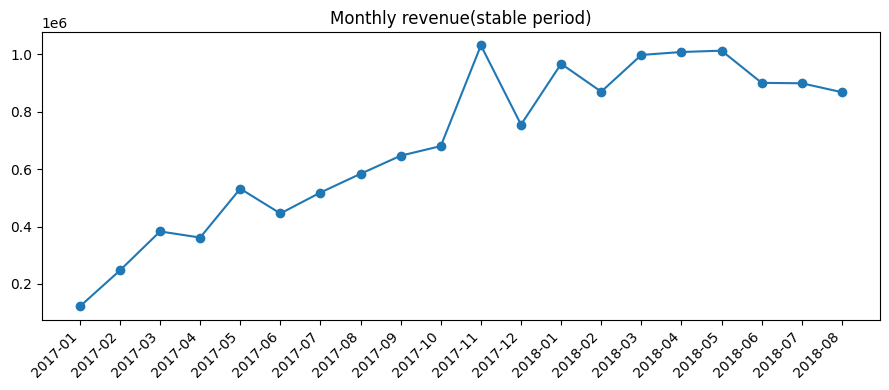

In [62]:
plt.figure(figsize=(9,4))
plt.plot(pivot.index, pivot.price, marker="o")
plt.xticks(rotation=45, ha='right')
plt.title("Monthly revenue(stable period)")
plt.tight_layout()
plt.show()

In [63]:
df_new = {
    't': list(range(len(pivot))),
    'ym': list(pivot.index),
    'revenue': list(pivot.price)
}
df_new = pd.DataFrame(df_new)
df_new

,t,ym,revenue
0,0,2017-01,121380.81
1,1,2017-02,247186.84
2,2,2017-03,382971.99
3,3,2017-04,361697.63
4,4,2017-05,532057.67
5,5,2017-06,445704.24
6,6,2017-07,518693.58
7,7,2017-08,583908.40
8,8,2017-09,647053.47
9,9,2017-10,680569.27


In [78]:
X = df_new[['t']]
y = df_new['revenue']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

model = LinearRegression().fit(X_train, y_train)
next_index = len(df_new)
y_pred = model.predict(X_test)

forecast = model.predict(pd.DataFrame({
    't': [next_index]
}))[0]
print(f"Predict revenue for next month: R${forecast:,.0f}")
print(f"Average growth for month: R${model.coef_[0]:,.0f}")
print("-" * 15)
print(f"MAE: R${mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE: R${np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"Predict accuracy(R2): {r2_score(y_test, y_pred):.1%}")
print(f"Predict revenue for next month: R${forecast:,.0f} +- {mean_absolute_error(y_test, y_pred):,.0f}")

Predict revenue for next month: R$1,109,031
Average growth for month: R$37,963
---------------
MAE: R$138,100
RMSE: R$148,958
Predict accuracy(R2): 85.4%
Predict revenue for next month: R$1,109,031 +- 138,100


In [77]:
df_new["month"] = df_new["ym"].str[-2:]
season = df_new.groupby('month')['revenue'].mean().round(0)
print("Average growth for number month: ")
print(season.sort_values(ascending=False))

Average growth for number month: 
month
11    1031580.0
05     772613.0
12     755290.0
08     726158.0
07     709089.0
03     690642.0
04     685111.0
10     680569.0
06     673338.0
09     647053.0
02     558669.0
01     544393.0
Name: revenue, dtype: float64
